# **Analyzing Nigeria’s Inflation Rate Trends**

As a Data Analyst, I am currently analyzing Nigeria’s inflation rate using Python to understand its impact on economic stability and consumer purchasing power. By leveraging data from sources like the National Bureau of Statistics (NBS) and the Central Bank of Nigeria (CBN), I track historical trends, identify key drivers such as exchange rates and food prices, and apply statistical models to uncover inflationary patterns. My analysis provides valuable insights for policymakers, businesses, and investors to navigate Nigeria’s economic landscape effectively.

In [39]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

sns.set_style('darkgrid')

In [40]:
df = pd.read_csv("NigeriaInflationRates.csv")

In [41]:
df.tail(5)

,Year,Month,Inflation_Rate,Crude Oil Price,Production,Crude Oil Export,CPI_Food,CPI_Energy,CPI_Health,CPI_Transport,CPI_Communication,CPI_Education
193,2024,2,31.70,86.08,1.32,0.87,846.846533,543.893969,494.844568,570.034088,234.228948,469.899712
194,2024,3,33.20,88.80,1.23,0.78,877.472863,558.813016,502.912687,579.821453,234.694654,476.890292
195,2024,4,33.69,93.12,1.28,0.83,899.453386,571.960431,510.095879,592.282753,235.335975,483.719840
196,2024,5,33.95,84.01,1.25,0.80,920.005281,583.894158,517.391784,606.408076,235.850405,490.779792
197,2024,6,34.19,83.64,1.28,0.83,943.458769,596.496022,524.747711,620.966251,236.061986,498.242239


### DATA CLEANING AND AGGREGATION

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               198 non-null    int64  
 1   Month              198 non-null    int64  
 2   Inflation_Rate     198 non-null    float64
 3   Crude Oil Price    197 non-null    float64
 4   Production         197 non-null    float64
 5   Crude Oil Export   197 non-null    float64
 6   CPI_Food           198 non-null    float64
 7   CPI_Energy         198 non-null    float64
 8   CPI_Health         198 non-null    float64
 9   CPI_Transport      198 non-null    float64
 10  CPI_Communication  198 non-null    float64
 11  CPI_Education      198 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 18.7 KB


In [43]:
df.isna().sum()

Year                 0
Month                0
Inflation_Rate       0
Crude Oil Price      1
Production           1
Crude Oil Export     1
CPI_Food             0
CPI_Energy           0
CPI_Health           0
CPI_Transport        0
CPI_Communication    0
CPI_Education        0
dtype: int64

In [44]:
df.fillna(0, inplace = True)

In [45]:
list(df.columns)

['Year',
 'Month',
 'Inflation_Rate',
 'Crude Oil Price',
 'Production',
 'Crude Oil Export',
 'CPI_Food',
 'CPI_Energy',
 'CPI_Health',
 'CPI_Transport',
 'CPI_Communication',
 'CPI_Education']

INFLATION RATE FROM 2008B - 2024

In [46]:
Inflation_Trend = df.groupby("Year")[['Inflation_Rate']].sum().reset_index()
Inflation_Trend

,Year,Inflation_Rate
0,2008,138.30
1,2009,151.10
2,2010,165.10
3,2011,130.20
4,2012,146.90
5,2013,102.20
6,2014,96.70
7,2015,108.12
8,2016,187.50
9,2017,198.57


Text(0.5, 1.0, 'INFLATION RATE TREND')

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


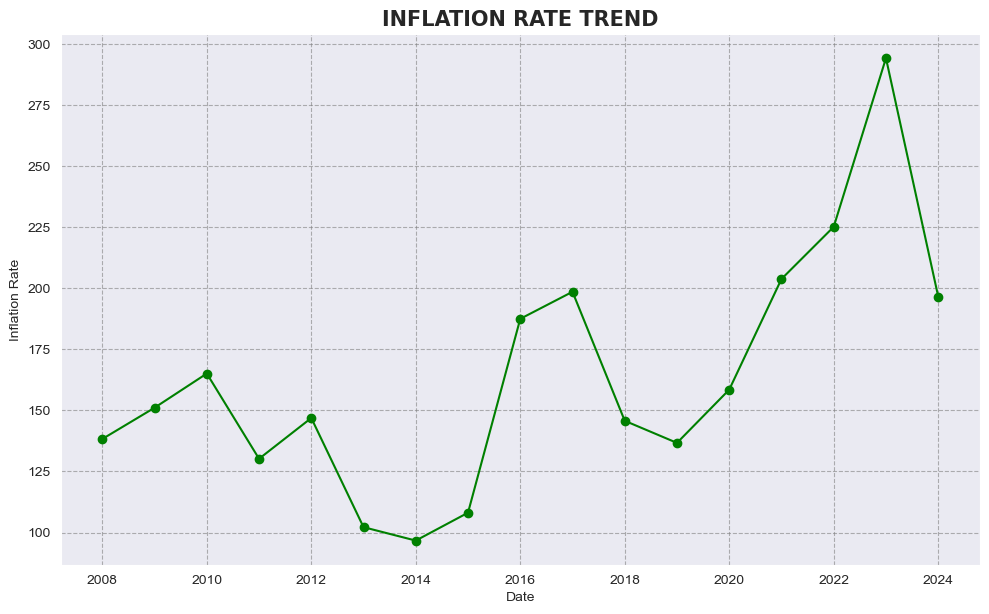

In [47]:
x= Inflation_Trend['Year']
y= Inflation_Trend['Inflation_Rate']
plt.figure(figsize=(10, 6))

plt.plot(x, y, color="Green", marker = "o")

plt.xlabel("Date")
plt.ylabel("Inflation Rate")
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)

plt.tight_layout()
plt.title("INFLATION RATE TREND", fontsize=15, fontweight="bold", fontfamily="Helvetica")


**Inflation Rate Trend (2008–2024)
Fluctuations:** Inflation peaked in 2023 and dropped sharply in 2024.

**Notable Trends:**
Lowest rate in 2014.
Significant rise from 2021 to 2023.

**Insights:** The 2023 peak likely reflects economic shocks, while 2024 indicates stabilization.
Action: Investigate 2023 drivers and monitor stabilization efforts.

### CRUDE OIL PRICE AND EXPORT 

In [48]:
Crude_oil= df.groupby("Year")[["Crude Oil Export", "Crude Oil Price"]].sum().reset_index()
Crude_oil["Revenue"] = Crude_oil['Crude Oil Export'] * Crude_oil['Crude Oil Price']
Crude_oil

,Year,Crude Oil Export,Crude Oil Price,Revenue
0,2008,19.79,1212.27,23990.8233
1,2009,19.93,766.80,15282.3240
2,2010,24.21,970.79,23502.8259
3,2011,23.17,1365.12,31629.8304
4,2012,22.42,1364.64,30595.2288
5,2013,20.80,1331.84,27702.2720
6,2014,21.07,1204.83,25385.7681
7,2015,20.12,631.84,12712.6208
8,2016,16.40,525.68,8621.1520
9,2017,17.27,649.03,11208.7481


### Crude Oil Export and Revenue Analysis (2008–2024)
**Trends:**

Crude Oil Export declined from 19.79 (2008) to 5.09 (2024), reflecting a steady drop.
Crude Oil Price peaked at 1365.12 (2011) and dropped significantly to 517.83 (2024).
Revenue (in million USD) peaked at 31,629.83M (2011) and declined to 2,635.75M (2024).

**Key Insights:**

The significant revenue drop after 2014 aligns with declining oil prices and exports.
Economic diversification is essential to reduce dependency on crude oil.

**Action:**
Investigate global oil price trends and prioritize alternative revenue sources for economic stability.

In [49]:
print('Average Crude oil Price from 2008-2024:', Crude_oil['Crude Oil Price'].mean() , 'USD')
print('Total Price Sold from 2008 - 2024: ',  Crude_oil["Crude Oil Price"].sum(),  "USD")
print("Average Crude Oil Export from 2008-2024", Crude_oil['Crude Oil Export'].mean(), "Million Barrels")
print ("Total Revenue: ", Crude_oil['Revenue'].sum(), "Million USD")
print("Total Crude Oil Export  from 2008-2024", Crude_oil['Crude Oil Export'].sum(), "Million Barrels")

Average Crude oil Price from 2008-2024: 925.744705882353 USD
Total Price Sold from 2008 - 2024:  15737.66 USD
Average Crude Oil Export from 2008-2024 17.046470588235294 Million Barrels
Total Revenue:  278728.2229 Million USD
Total Crude Oil Export  from 2008-2024 289.79 Million Barrels


### Key Insights
**Revenue Significance:** Despite significant fluctuations in global crude oil prices, total revenue of over $278 billion USD highlights oil's pivotal role in sustaining the economy. This reinforces the dependence of Nigeria's economy on crude oil exports.

**Consistency in Export Volumes:** The average export volume of 17.05 million barrels reflects steady production capabilities, even amid global market volatility and domestic challenges.

**Declining Trends:** The drop in both prices and export volumes in later years emphasizes the need to address factors affecting crude oil demand and production capacity, including geopolitical influences and alternative energy adoption.

### Action Plan
Stabilize Exports: Ensure consistent production levels by addressing operational inefficiencies and investing in modern oil extraction technologies.
Market Diversification: Reduce over-reliance on crude oil by channeling oil revenues into other sectors such as agriculture, technology, and manufacturing.
Global Positioning: Strengthen Nigeria's position in the global oil market by exploring new trade partnerships and improving competitive pricing strategies.

### Growth Rate of Crude Oil Price and Export 

In [50]:
Crude_oil['Export Growth Rate'] = Crude_oil['Crude Oil Export'].pct_change() * 100
Crude_oil['Price Growth Rate'] = Crude_oil['Crude Oil Price'].pct_change() * 100
Crude_oil.fillna(0, inplace = True)

In [51]:
Crude_oil

,Year,Crude Oil Export,Crude Oil Price,Revenue,Export Growth Rate,Price Growth Rate
0,2008,19.79,1212.27,23990.8233,0.000000,0.000000
1,2009,19.93,766.80,15282.3240,0.707428,-36.746764
2,2010,24.21,970.79,23502.8259,21.475163,26.602765
3,2011,23.17,1365.12,31629.8304,-4.295746,40.619495
4,2012,22.42,1364.64,30595.2288,-3.236944,-0.035162
5,2013,20.80,1331.84,27702.2720,-7.225691,-2.403564
6,2014,21.07,1204.83,25385.7681,1.298077,-9.536431
7,2015,20.12,631.84,12712.6208,-4.508780,-47.557747
8,2016,16.40,525.68,8621.1520,-18.489066,-16.801722
9,2017,17.27,649.03,11208.7481,5.304878,23.464846


### Key Insights
**Revenue Dependence on Price: **Revenue correlates strongly with crude oil prices, as seen in years like 2011 and 2021, where price increases significantly boosted revenue.

**Declining Exports:** The negative trend in export growth indicates the need for increased production efficiency or exploration of alternative energy markets.

**Volatility Impact: **Both price and export fluctuations contribute to revenue unpredictability, emphasizing the need for diversification of revenue streams.

### Recommendations
**Stabilize Production:** Invest in modern technology to stabilize and potentially increase export volumes.

**Economic Diversification**: Use oil revenue to strengthen other sectors and reduce dependence on crude oil exports.

**Market Adaptation:** Explore long-term agreements with buyers to mitigate price volatility and stabilize revenues.

### CORRELATION BETWEEN THE PRICE AND BARREL EXPORTED

In [52]:
correlation = Crude_oil[["Crude Oil Price", "Crude Oil Export"]].corr()

<Axes: >

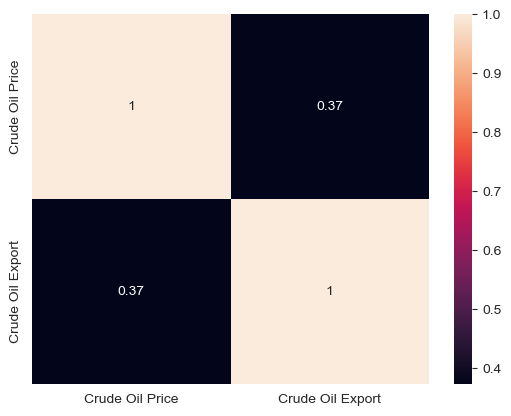

In [53]:
sns.heatmap(correlation, annot= True)

**The key insights from this heatmap are:**

Crude Oil Price to Crude Oil Export: There is a positive correlation of 0.37, suggesting a weak to moderate relationship.
Diagonal Values (1): These indicate a perfect correlation of a variable with itself.

### INFLATION WITH CRUDE OIL TREND

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


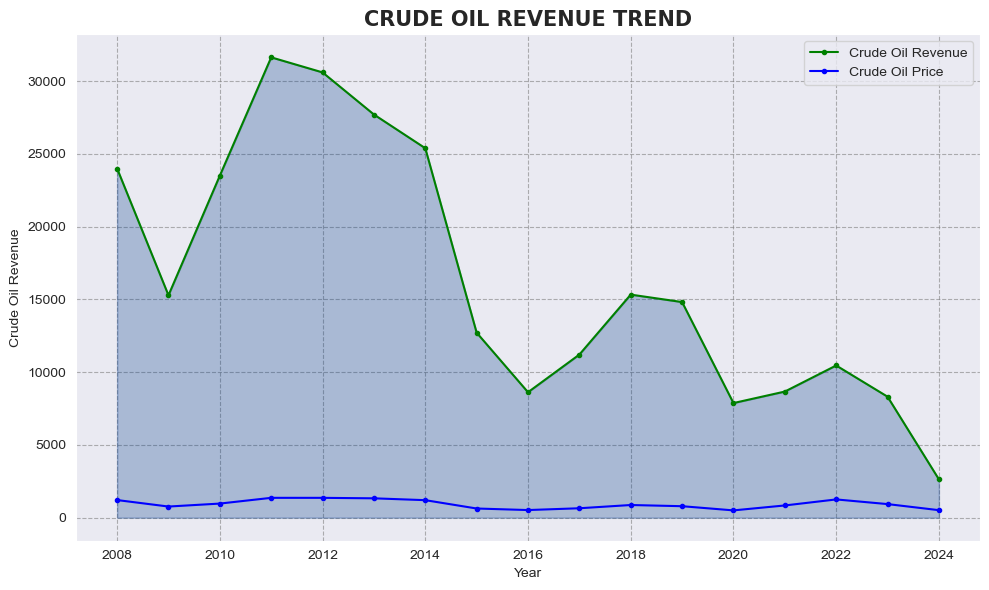

In [54]:
Z = Crude_oil['Revenue']
A = Crude_oil['Crude Oil Price']
plt.figure(figsize=(10, 6))

plt.plot(x, Z, marker = ".",  label = 'Crude Oil Revenue', color = 'Green')
plt.fill_between(x, Z, color="green", alpha=0.15)



plt.plot(x, A, marker = ".",  label = 'Crude Oil Price', color = 'blue')
plt.fill_between(x, Z, color="blue", alpha=0.15)

plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)

plt.xlabel("Year")
plt.ylabel("Crude Oil Revenue")
plt.title("CRUDE OIL REVENUE TREND", fontsize=15, fontweight="bold", fontfamily="Helvetica")

plt.legend()

plt.tight_layout()

plt.show()

### Insights:
The significant decline in revenue and prices after 2014 might be attributed to global market dynamics, increased competition, or reduced demand for crude oil.
The recovery in crude oil prices in 2022 suggests a slight improvement in market conditions but is not enough to reverse the declining revenue trend.

### Recommendations:
**Diversification:** The country could focus on diversifying its economy to reduce dependence on crude oil exports.

**Value Addition:** Invest in downstream activities (e.g., refining) to add value to crude oil and increase export revenue.

**Stabilization Mechanisms: **Implement policies to stabilize revenue amidst volatile global oil prices.

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


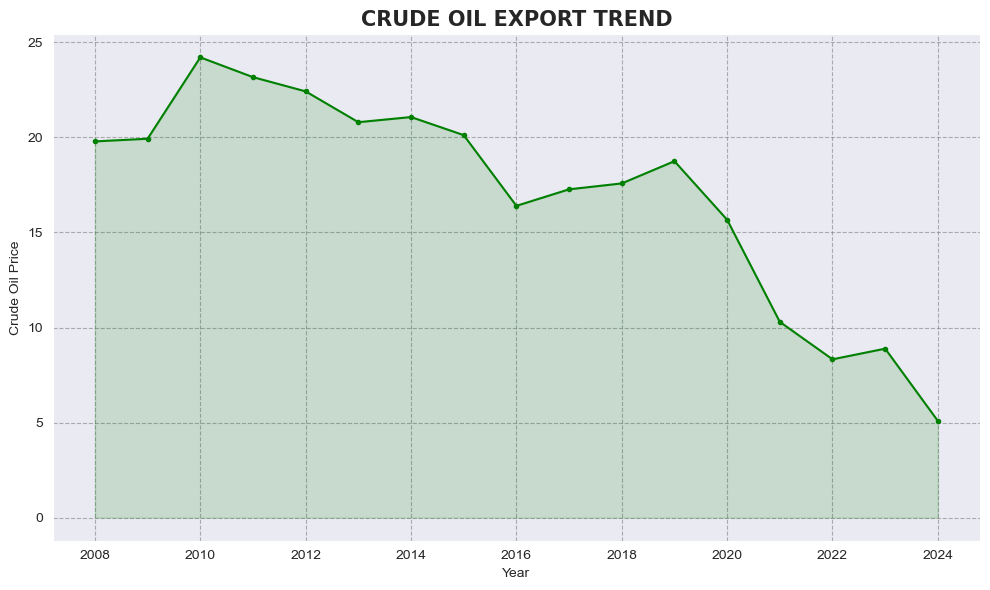

In [55]:
W = Crude_oil['Crude Oil Export']
plt.figure(figsize=(10, 6))

plt.plot(x, W, marker = ".",  label = 'Crude Oil Export', color = 'Green')
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)


plt.fill_between(x, W, color="green", alpha=0.15)
plt.xlabel("Year")
plt.ylabel("Crude Oil Price")

plt.title("CRUDE OIL EXPORT TREND", fontsize=15, fontweight="bold", fontfamily="Helvetica")

plt.tight_layout()

plt.show()

### Insights:
 Crude oil exports have declined significantly since 2011, reaching their lowest point in 2024, impacting revenue and competitiveness.

### Recommendations:
Diversify markets and trade partnerships.

Invest in renewable energy solutions.

Optimize production costs to stay competitive.

### CONSUMER PRICE INDEX ON FOOD, ENERGY, HEALTH, TRANSPORT, COMMUNICATION AND EDUCATION

In [56]:
CPI=df.groupby("Year")[["CPI_Education","CPI_Communication", "CPI_Transport", "CPI_Health", "CPI_Energy"]].sum().reset_index()

In [57]:
CPI

,Year,CPI_Education,CPI_Communication,CPI_Transport,CPI_Health,CPI_Energy
0,2008,957.359004,1119.695632,1059.438882,1086.615758,1067.579720
1,2009,1132.620799,1185.050148,1135.117868,1204.280715,1156.102056
2,2010,1282.393200,1215.412503,1292.952466,1304.514048,1272.231715
3,2011,1349.361906,1268.982826,1430.073784,1425.557870,1469.951185
4,2012,1496.789724,1368.108383,1622.570546,1563.169882,1730.773907
5,2013,1601.999316,1421.562204,1741.413536,1670.516032,1896.771971
6,2014,1704.682818,1482.863393,1858.959218,1784.273595,2007.473410
7,2015,1853.849144,1528.799718,2018.060232,1930.482521,2152.088376
8,2016,2163.947049,1604.210904,2336.280241,2127.914192,2624.078215
9,2017,2493.396521,1661.345009,2650.111623,2354.332935,2961.240159


### CPI TRENDS

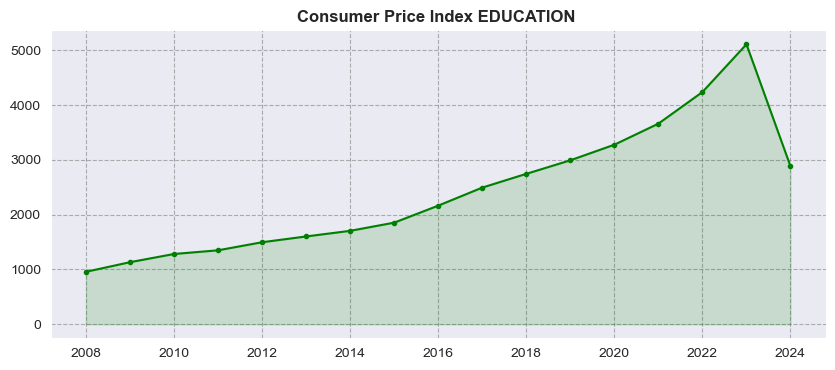

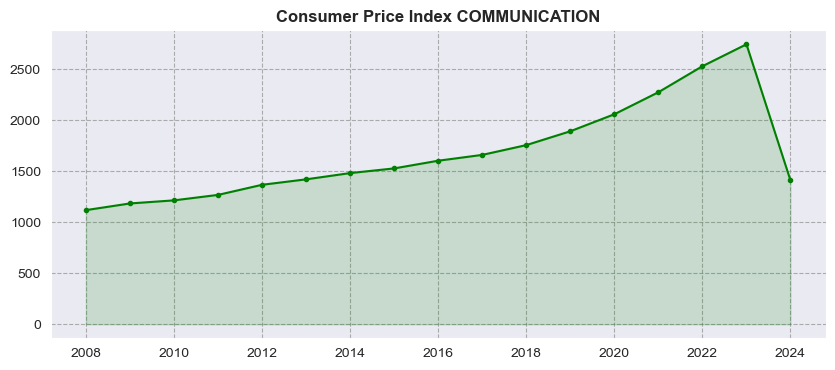

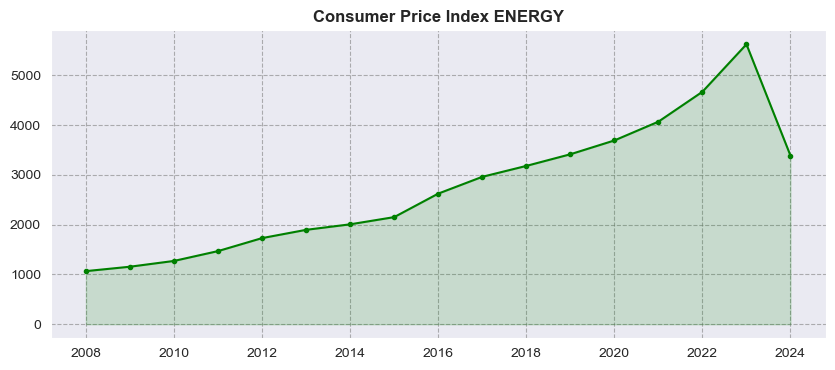

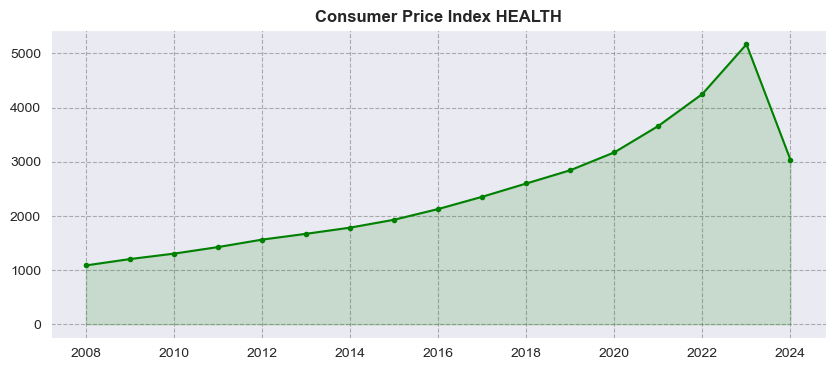

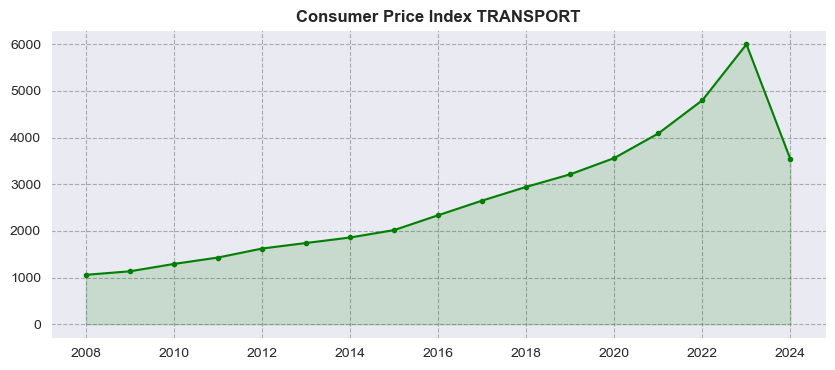

In [58]:
a = CPI['CPI_Education']
plt.figure(figsize=(10,4))
ax1 = plt.plot( x, a, color = "Green", marker = ".")
plt.fill_between(x, a, color="Green", alpha=0.15)
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)
plt.title("Consumer Price Index EDUCATION ", fontfamily = "Arial", fontweight = "bold", fontsize = 12)
plt.show(ax1)

b = CPI["CPI_Communication"]
plt.figure(figsize=(10,4))
ax2 = plt.plot( x, b, color = "Green", marker = ".")
plt.fill_between(x, b, color="Green", alpha=0.15)
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)
plt.title("Consumer Price Index COMMUNICATION", fontfamily = "Arial", fontweight = "bold", fontsize = 12)
plt.show(ax2)

c= CPI['CPI_Energy']
plt.figure(figsize=(10,4))
ax3 = plt.plot( x, c, color = "Green", marker = ".")
plt.fill_between(x, c, color="Green", alpha=0.15)
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)
plt.title("Consumer Price Index ENERGY", fontfamily = "Arial", fontweight = "bold", fontsize = 12)
plt.show(ax3)

d = CPI['CPI_Health']
plt.figure(figsize=(10,4))
ax4 = plt.plot( x, d, color = "Green", marker = ".")
plt.fill_between(x, d, color="Green", alpha=0.15)
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)
plt.title("Consumer Price Index HEALTH", fontfamily = "Arial", fontweight = "bold", fontsize = 12)
plt.show(ax4)

e = CPI['CPI_Transport']
plt.figure(figsize=(10,4))
ax4 = plt.plot( x, e, color = "Green", marker = ".")
plt.fill_between(x, e, color="Green", alpha=0.15)
plt.grid(True, color= "grey", linestyle="--", alpha = 0.6)
plt.title("Consumer Price Index TRANSPORT", fontfamily = "Arial", fontweight = "bold", fontsize = 12)
plt.show(ax4)


### Insights (2008–2024):

Education, Health, Transport, Energy: CPI peaked in 2023, followed by a sharp decline in 2024.

Communication: Gradual rise until 2023, steep drop in 2024.

2023: Highest CPI across all categories.

2024: Significant CPI decline suggests economic shifts or stabilization.


### Actionable Steps:
Investigate 2024 CPI drop causes.

Focus on stabilizing key sectors like education and health.

### GROWTH RATE

In [59]:
CPI['Health Growth Rate'] = CPI['CPI_Health'].pct_change()
CPI['Education Growth Rate'] = CPI['CPI_Education'].pct_change()
CPI['Communication Growth Rate'] = CPI['CPI_Communication'].pct_change()
CPI['Transport Growth Rate'] = CPI['CPI_Transport'].pct_change()
CPI['Energy Growth Rate'] = CPI['CPI_Energy'].pct_change()

In [60]:
CPI_growth_rate = CPI[['Year', 'Health Growth Rate', 'Education Growth Rate', 'Communication Growth Rate', 'Transport Growth Rate', 'Energy Growth Rate']]
CPI_growth_rate.fillna(0, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_50108\1483687933.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CPI_growth_rate.fillna(0, inplace = True)


In [61]:
CPI_growth_rate

,Year,Health Growth Rate,Education Growth Rate,Communication Growth Rate,Transport Growth Rate,Energy Growth Rate
0,2008,0.000000,0.000000,0.000000,0.000000,0.000000
1,2009,0.108286,0.183068,0.058368,0.071433,0.082919
2,2010,0.083231,0.132235,0.025621,0.139047,0.100449
3,2011,0.092788,0.052222,0.044076,0.106053,0.155412
4,2012,0.096532,0.109257,0.078114,0.134606,0.177436
5,2013,0.068672,0.070290,0.039071,0.073244,0.095910
6,2014,0.068097,0.064097,0.043122,0.067500,0.058363
7,2015,0.081943,0.087504,0.030978,0.085586,0.072038
8,2016,0.102271,0.167272,0.049327,0.157686,0.219317
9,2017,0.106404,0.152245,0.035615,0.134330,0.128488


### Insight

**2023:** Peak growth rates across all sectors, especially in Transport (24.94%), Energy *(20.42%)*, and Education *(20.56%)*.

**2024:** Significant negative growth rates in all sectors, with Communication *(-48.65%)* and Education *(-43.57%)* experiencing the steepest declines.
Trend: Growth rates were relatively stable until a sharp increase in 2023, followed by a steep drop in 2024.

### SECTOR WITH THE HIGHEST VOLATLTILITY

In [62]:
sector_volatility = CPI_growth_rate.drop(columns='Year').std()

In [63]:
print ("SECTOR VOLATILITY")
sector_volatility

SECTOR VOLATILITY


Health Growth Rate           0.133152
Education Growth Rate        0.142420
Communication Growth Rate    0.135359
Transport Growth Rate        0.138753
Energy Growth Rate           0.135434
dtype: float64

### Insights:

**Highest Growth:** The Education sector has the highest growth rate at 0.142420, indicating the most volatility or change in this sector.
**Stable Growth:** The Health sector exhibits the lowest growth rate at 0.133152, indicating more stability relative to other sectors.

### Key Takeaways:

**Education:** This sector is experiencing the fastest growth, likely due to increased investments, reforms, or demand for educational services.

**Energy and Communication:** These sectors show similar growth rates (0.135434 and 0.135359, respectively), suggesting consistent performance and comparable volatility.

**Transport:** Growth in this sector (0.138753) is notable, possibly reflecting infrastructure development or higher demand for transportation services.
### Recommendations:

Focus on Education for emerging opportunities due to its high growth.
Monitor Health for stability and potential long-term investment.
Diversify investments in Energy and Communication, as they offer steady but moderate growth.

In [64]:
print ('most_volatile_sector: ',  sector_volatility.idxmax())
print ('least_volatile_sector: ',  sector_volatility.idxmin())

most_volatile_sector:  Education Growth Rate
least_volatile_sector:  Health Growth Rate


Real-World Implications
High Volatility: Indicates price instability, which may affect consumer budgeting and planning (e.g., CPI_Education shows high volatility, suggesting fluctuating tuition or educational costs).
Low Volatility: Reflects stable pricing, offering predictability for consumers (e.g., CPI_Communication is relatively stable).

### INFLATION PREDICTIONS

**ARIMA**

In [65]:
model = ARIMA(df['Inflation_Rate'], order=(1, 1, 1))  
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:         Inflation_Rate   No. Observations:                  198
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -216.061
Date:                Fri, 07 Feb 2025   AIC                            438.122
Time:                        08:16:58   BIC                            447.971
Sample:                             0   HQIC                           442.109
                                - 198                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8149      0.113      7.231      0.000       0.594       1.036
ma.L1         -0.6066      0.136     -4.458      0.000      -0.873      -0.340
sigma2         0.5245      0.034     15.210      0.0

findfont: Font family 'Helveticaica' not found.
findfont: Font family 'Helveticaica' not found.
findfont: Font family 'Helveticaica' not found.
findfont: Font family 'Helveticaica' not found.
findfont: Font family 'Helveticaica' not found.


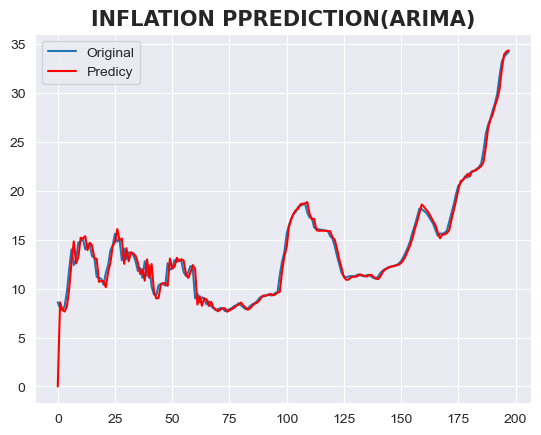

In [66]:
fitted_values = model_fit.fittedvalues
plt.plot(df['Inflation_Rate'], label='Original')
plt.plot(fitted_values, label='Predicy', color='red')
plt.title("INFLATION PPREDICTION(ARIMA)", fontsize=15, fontweight="bold", fontfamily="Helveticaica")
plt.legend()
plt.show()

In [67]:
forecast = model_fit.forecast(steps=12)
print(forecast)

198    34.468969
199    34.696304
200    34.881564
201    35.032535
202    35.155563
203    35.255820
204    35.337522
205    35.404102
206    35.458359
207    35.502573
208    35.538604
209    35.567967
Name: predicted_mean, dtype: float64


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


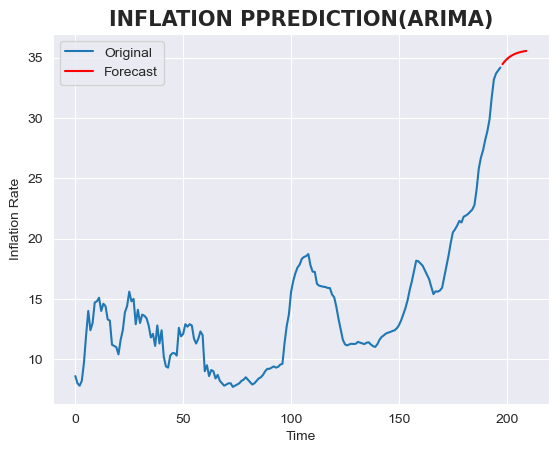

In [68]:
plt.plot(df['Inflation_Rate'], label='Original')
plt.plot(range(len(df), len(df) + len(forecast)), forecast, label='Forecast', color='red')

plt.title("INFLATION PPREDICTION(ARIMA)", fontsize=15, fontweight="bold", fontfamily="Helvetica")
plt.xlabel('Time')
plt.ylabel('Inflation Rate')
plt.legend()

### Trend Analysis:

The forecast suggests that inflation will maintain its increasing trajectory in the immediate future.
This aligns with recent growth rates observed in economic indicators, likely driven by factors such as rising sector costs and macroeconomic pressures.
### Practical Application:

Policymakers and economic stakeholders can use this forecast to anticipate inflationary pressure and adjust fiscal or monetary policies accordingly.
Businesses and individuals should prepare for potential cost escalations in goods and services.

### USING PROPHET

In [69]:
df['ds'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df['y'] = df[['Inflation_Rate']
]

In [70]:
Pre = df[['ds', 'y']]
model = Prophet()
model.fit(Pre)

08:17:01 - cmdstanpy - INFO - Chain [1] start processing
08:17:01 - cmdstanpy - INFO - Chain [1] done processing


In [71]:
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)


c:\Anaconda\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [72]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2008-01-01,12.279474,8.814699,15.678472
1,2008-02-01,12.553872,9.035121,16.373245
2,2008-03-01,12.196461,8.858433,15.763335
3,2008-04-01,12.392520,8.849125,15.858081
4,2008-05-01,12.483719,9.061264,15.987905
...,...,...,...,...
205,2025-01-31,30.616231,27.224943,34.140034
206,2025-02-28,31.122832,27.790467,34.473276
207,2025-03-31,30.839101,27.611476,34.309295
208,2025-04-30,30.921859,27.510470,34.171031


In [73]:

forecast_2025 = forecast[forecast['ds'].dt.year == 2025][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]


forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2008-01-01,12.407004,8.814699,15.678472,12.407004,12.407004,-0.127530,-0.127530,-0.127530,-0.127530,-0.127530,-0.127530,0.0,0.0,0.0,12.279474
1,2008-02-01,12.383044,9.035121,16.373245,12.383044,12.383044,0.170828,0.170828,0.170828,0.170828,0.170828,0.170828,0.0,0.0,0.0,12.553872
2,2008-03-01,12.360630,8.858433,15.763335,12.360630,12.360630,-0.164169,-0.164169,-0.164169,-0.164169,-0.164169,-0.164169,0.0,0.0,0.0,12.196461
3,2008-04-01,12.336669,8.849125,15.858081,12.336669,12.336669,0.055851,0.055851,0.055851,0.055851,0.055851,0.055851,0.0,0.0,0.0,12.392520
4,2008-05-01,12.313482,9.061264,15.987905,12.313482,12.313482,0.170237,0.170237,0.170237,0.170237,0.170237,0.170237,0.0,0.0,0.0,12.483719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,2025-01-31,30.293406,27.224943,34.140034,30.205755,30.370496,0.322825,0.322825,0.322825,0.322825,0.322825,0.322825,0.0,0.0,0.0,30.616231
206,2025-02-28,30.563964,27.790467,34.473276,30.454786,30.656354,0.558867,0.558867,0.558867,0.558867,0.558867,0.558867,0.0,0.0,0.0,31.122832
207,2025-03-31,30.863511,27.611476,34.309295,30.737118,30.975513,-0.024411,-0.024411,-0.024411,-0.024411,-0.024411,-0.024411,0.0,0.0,0.0,30.839101
208,2025-04-30,31.153395,27.510470,34.171031,31.002291,31.285181,-0.231537,-0.231537,-0.231537,-0.231537,-0.231537,-0.231537,0.0,0.0,0.0,30.921859


In [74]:
forecast_2025.set_index('ds', inplace=True)
monthly_forecast_2025 = forecast_2025.resample('M').mean()
monthly_forecast_2025

C:\Users\DELL\AppData\Local\Temp\ipykernel_50108\3843214972.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_forecast_2025 = forecast_2025.resample('M').mean()


,yhat,yhat_lower,yhat_upper
ds,,,
2025-01-31,30.616231,27.224943,34.140034
2025-02-28,31.122832,27.790467,34.473276
2025-03-31,30.839101,27.611476,34.309295
2025-04-30,30.921859,27.510470,34.171031
2025-05-31,30.585553,27.249049,33.974270


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


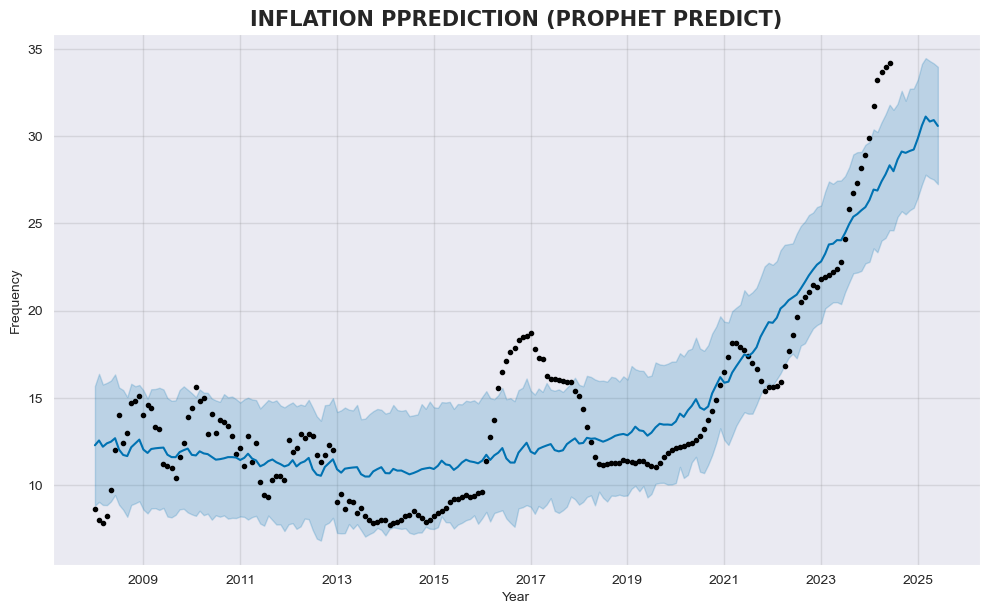

In [75]:
model.plot(forecast)
plt.title("INFLATION PPREDICTION (PROPHET PREDICT)", fontsize=15, fontweight="bold", fontfamily="Helvetica")
plt.xlabel('Year')
plt.ylabel("Frequency")
plt.show()

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


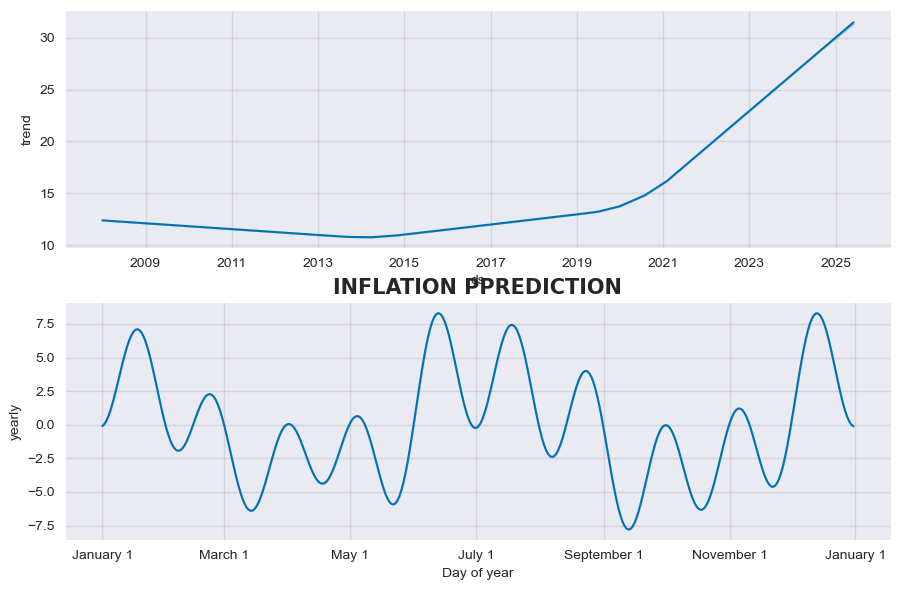

In [76]:
model.plot_components(forecast)
plt.title("INFLATION PPREDICTION", fontsize=15, fontweight="bold", fontfamily="Helvetica")

plt.show()

### Key Insights
**Trend: **Inflation is projected to rise steadily, exceeding 30% in early 2025.

**Seasonality: **Peaks occur mid-year, with dips at year-end.

**Predictions (2025):**
January: 30.62%

February: 31.12%

March: 30.84%

### Recommendations

Stabilize inflation with targeted monetary policies.
Address seasonal disruptions in supply chains.
Educate citizens on managing inflation impacts.
Diversify the economy to reduce vulnerability.


### Brief Analysis: Prophet and ARIMA Models
**Prophet Model:**

Projects inflation exceeding 30% by mid-2025, highlighting long-term growth trends and recurring seasonal patterns.
Confidence intervals emphasize increasing uncertainty over time.

**ARIMA Model:**

Focuses on short-term trends with precise forecasts.

Aligns well with Prophet’s projections, providing accuracy for immediate policy actions.

**Combined Insights:**

Both models predict sustained inflation growth driven by macroeconomic factors like energy prices and currency devaluation.

Prophet’s long-term insights complement ARIMA’s short-term precision for a comprehensive view.

### Recommendations:
**Short-term:** Implement tax reliefs, tighten interest rates, and monitor market volatility (ARIMA).

**Long-term:** Stabilize currency, boost local production, and prepare for seasonal demand (Prophet).

**Integrated Approach:** Use both models to create an inflation management dashboard for real-time insights and effective decision-making.

### Conclusion:
Prophet and ARIMA together provide a robust framework for managing Nigeria’s inflation through precise short-term actions and strategic long-term planning.